In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
"""
This notebook does multi-label classification using xgboost. 
"""

Data excludes Land_Vehicle class

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report,
    multilabel_confusion_matrix, f1_score
)


train_p = Path(r".\Data_v3\Bootstrapped_Audios_No_Land_Vehicles\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v3\Bootstrapped_Audios_No_Land_Vehicles\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)


label_cols = ["label_overlay_Airplanes", "label_overlay_Drones", "label_overlay_Explosion",
              "label_overlay_Gunshots", "label_overlay_Helicopter", "label_overlay_shortened_unlabeled"]
non_feature_cols = ["filepath", "label_base"] + label_cols
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols]
y_train = train_df[label_cols]
X_test = test_df[feature_cols]
y_test = test_df[label_cols]

target_names = [c.replace("label_overlay_", "") for c in label_cols]

Cross Validation

In [2]:
clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",       # independent per-label probability
    eval_metric="logloss",
    tree_method="hist",
    multi_strategy="multi_output_tree", # native multi-label support, shares trees across labels
    n_jobs=-1,
)

cv = MultilabelStratifiedKFold(n_splits=10, shuffle=True)

scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 3)}")


=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.5215  std=0.0417  folds=[0.561 0.592 0.527 0.483 0.482 0.443 0.509 0.556 0.522 0.538]
f1_macro       : mean=0.8713  std=0.0140  folds=[0.888 0.878 0.856 0.864 0.873 0.854 0.894 0.883 0.851 0.873]
precision_macro: mean=0.8428  std=0.0185  folds=[0.854 0.844 0.833 0.839 0.861 0.81  0.867 0.858 0.813 0.848]
recall_macro   : mean=0.9037  std=0.0143  folds=[0.926 0.917 0.882 0.894 0.885 0.904 0.923 0.909 0.895 0.903]


Test on Unseen


=== Final Held-Out Test ===
Test Subset Accuracy: 0.4622
                     precision    recall  f1-score   support

          Airplanes       0.87      0.88      0.87       240
             Drones       0.83      0.82      0.83       225
          Explosion       0.80      0.92      0.86       242
           Gunshots       0.76      0.86      0.81       225
         Helicopter       0.91      0.89      0.90       239
shortened_unlabeled       0.81      0.93      0.86       230

          micro avg       0.83      0.88      0.85      1401
          macro avg       0.83      0.88      0.85      1401
       weighted avg       0.83      0.88      0.86      1401
        samples avg       0.80      0.86      0.81      1401



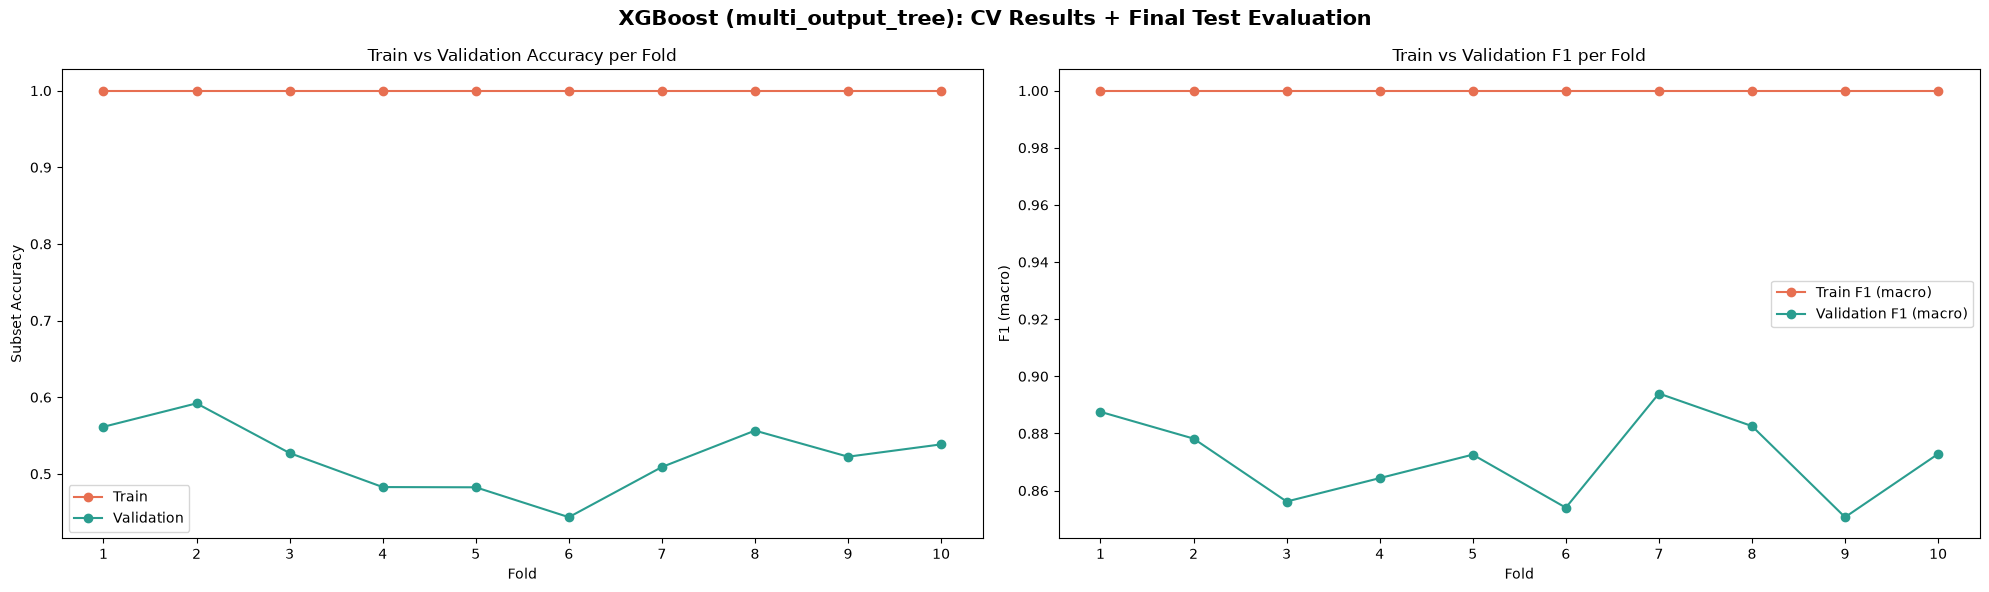

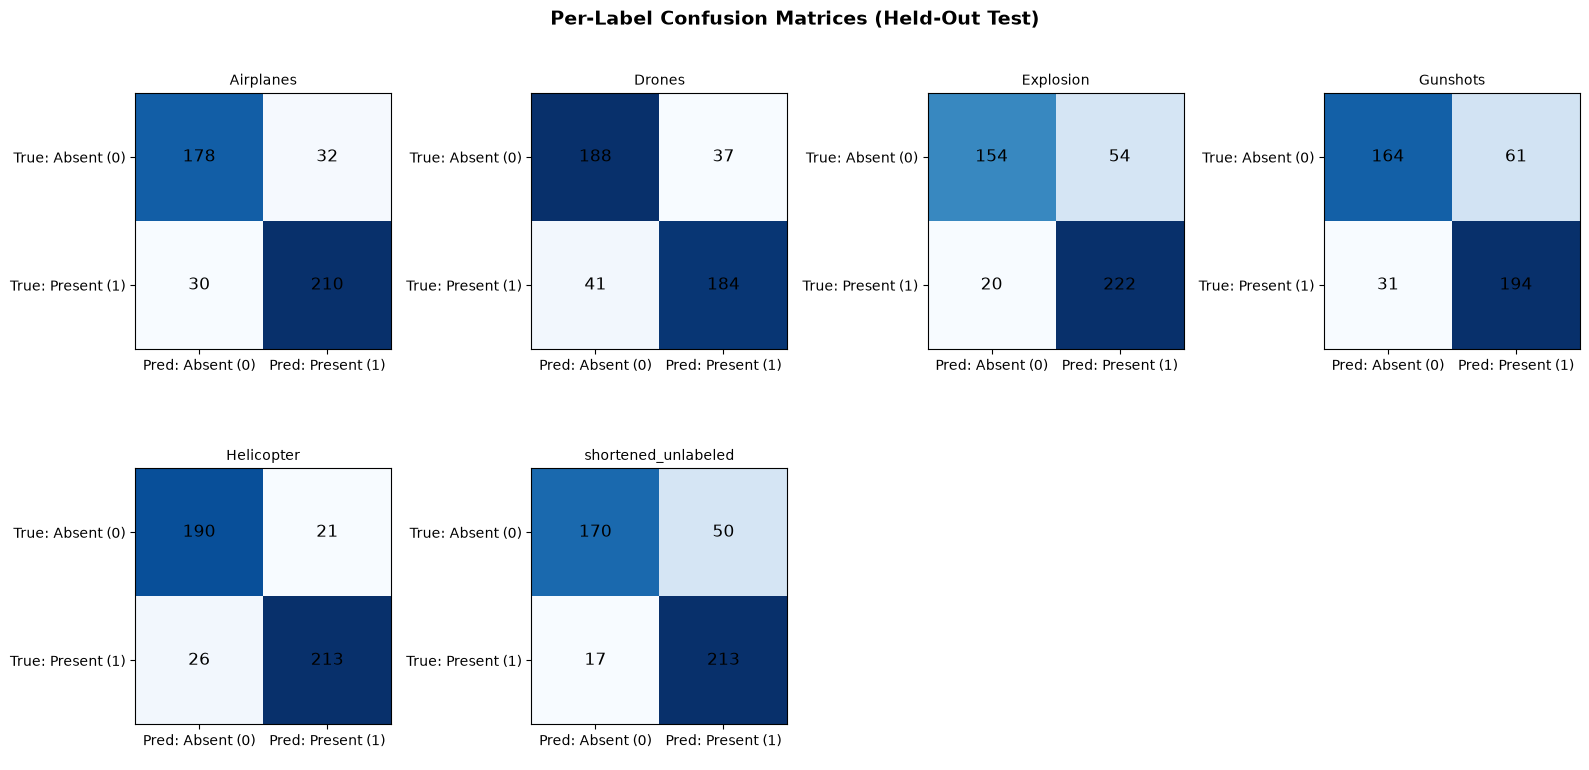

In [3]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)  # subset (exact-match) accuracy

print("\n=== Final Held-Out Test ===")
print(f"Test Subset Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# --- Plot 1: Train vs validation accuracy per fold ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("XGBoost (multi_output_tree): CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Subset Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

ax = axes[1]
ax.plot(folds, cv_results["train_f1_macro"], marker="o", label="Train F1 (macro)", color="#e76f51")
ax.plot(folds, cv_results["test_f1_macro"], marker="o", label="Validation F1 (macro)", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (macro)")
ax.set_title("Train vs Validation F1 per Fold")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Multi-label confusion matrices (one per label, grid) ---
mcm = multilabel_confusion_matrix(y_test, y_pred)  # shape (n_labels, 2, 2)

n_labels = len(target_names)
ncols = 4
nrows = int(np.ceil(n_labels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, name in enumerate(target_names):
    ax = axes[i]
    cm = mcm[i]
    ax.imshow(cm, cmap="Blues")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                     color="black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Absent (0)", "Pred: Present (1)"])
    ax.set_yticklabels(["True: Absent (0)", "True: Present (1)"])
    ax.set_title(name, fontsize=10)

for j in range(n_labels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-Label Confusion Matrices (Held-Out Test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

from pathlib import Path

# # SAVE MODEL
# model_dir = Path("./Model/xgboost")
# model_dir.mkdir(parents=True, exist_ok=True)

# clf.save_model(model_dir / "multilabel_xgb_model.json")
# with open(model_dir / "feature_cols.json", "w") as f:
#     json.dump(feature_cols, f)
# with open(model_dir / "target_names.json", "w") as f:
#     json.dump(target_names, f)

Feature Importance

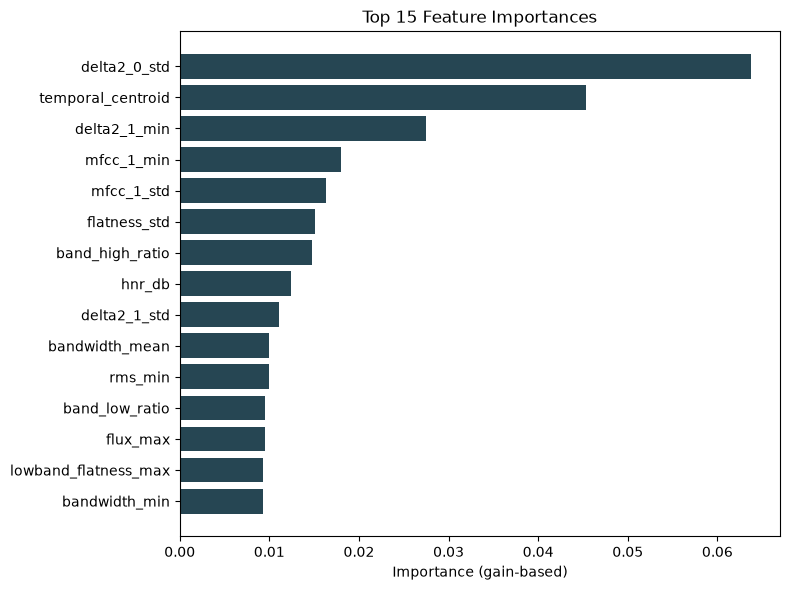

In [4]:
feature_names = np.array(X_train.columns)
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()